# setup_and_data_generation

In [1]:
# !pip install stable-baselines3 shimmy gymnasium pandas numpy matplotlib
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import os
import yfinance as yf
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# --- Configuration ---
WINDOW_SIZE = 60       
RISK_AVERSION = 4.0    # You increased this to 4.0 (Good choice for Tech stocks, they are volatile!)
TX_COST_BPS = 0.0010   
REBALANCE_THRESHOLD = 0.05 

def load_real_data(tickers=None, benchmark='QQQ', start='2015-01-01', end='2025-10-31'):
    """
    Robust loader for Yahoo Finance data.
    Fixes: Timezones, Missing Values (FFILL), and MultiIndex formatting.
    """
    if tickers is None:
        # Tech heavy portfolio
        tickers = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
    
    # Download everything at once
    all_tickers = tickers + [benchmark]
    print(f"Downloading {len(all_tickers)} assets...")
    
    # auto_adjust=True gives us 'Close' adjusted for splits/dividends
    raw_data = yf.download(all_tickers, start=start, end=end, progress=False, auto_adjust=True)
    
    # 1. Handle YFinance MultiIndex (Price Type, Ticker)
    # The columns usually look like ('Close', 'AAPL'). We just want the 'Close' slice.
    if isinstance(raw_data.columns, pd.MultiIndex):
        try:
            # Try grabbing the 'Close' cross-section directly
            df = raw_data['Close'].copy()
        except KeyError:
            # Fallback if yfinance changes format or case
            df = raw_data['close'].copy()
    else:
        df = raw_data.copy()

    # 2. Rename Benchmark to 'SPY' 
    # (The Environment expects a column named 'SPY' for the market regime logic)
    if benchmark in df.columns:
        df = df.rename(columns={benchmark: 'SPY'})
    
    # 3. Data Cleaning (Crucial for RL)
    # Forward Fill first (carry forward yesterday's price to fill holidays)
    df = df.ffill()
    # Then drop any remaining NaNs (usually the first few days if data starts at different times)
    df = df.dropna().round(2)
    
    # 4. Strip Timezone (Make it naive)
    df.index = df.index.tz_localize(None)
    
    # 5. Reorder: Assets first, Benchmark last
    # This ensures the matrix slicing in the Env works as expected
    asset_cols = [t for t in tickers if t in df.columns]
    final_cols = asset_cols + ['SPY']
    
    # Verify we didn't lose the benchmark
    if 'SPY' not in df.columns:
        raise ValueError("Benchmark failed to download or rename!")
        
    return df[final_cols]

# Load and Verify

df_full = load_real_data()
print(f"Data Successfully Loaded: {df_full.shape}")
print(f"Date Range: {df_full.index.min()} to {df_full.index.max()}")
print("Sample:")
df_full.tail()


Data Successfully Loaded: (2724, 8)
Date Range: 2015-01-02 00:00:00 to 2025-10-30 00:00:00
Sample:


Ticker,NVDA,MU,AAPL,AMD,ASML,MSFT,GOOG,SPY
Date,,,,,,,,
2025-10-24,186.26,219.02,262.57,252.92,1031.27,522.63,260.51,617.10
2025-10-27,191.49,220.10,268.55,259.67,1058.10,530.53,269.93,628.09
2025-10-28,201.03,221.91,268.74,258.01,1050.62,541.06,268.43,632.92
2025-10-29,207.04,226.63,269.44,264.33,1070.84,540.54,275.17,635.77
2025-10-30,202.89,224.01,271.14,254.84,1075.45,524.78,281.90,626.05


# Feature Engineering (The Processor)

Vectorized calculation of the "Golden 4" indicators.

In [3]:
class FinancialFeatureEngineer:
    def preprocess_data(self, df):
        """
        Input: DataFrame (Time, Assets + SPY)
        Output: 
            - features: 3D Array (Time, Assets, Num_Features)
            - prices: 2D Array (Time, Assets)
            - benchmark: 1D Array (Time)
        """
        data = df.copy()
        asset_cols = [c for c in data.columns if c != 'SPY']
        
        # We will build a list of feature matrices (one per feature type)
        # 1. Log Returns (Momentum/Volatility proxy)
        log_ret = np.log(data[asset_cols] / data[asset_cols].shift(1)).fillna(0)
        
        # 2. Rolling Volatility (Risk) - Normalized
        # Z-Score relative to last 252 days
        roll_std = log_ret.rolling(20).std()
        roll_mean_std = roll_std.rolling(252).mean()
        roll_std_std = roll_std.rolling(252).std()
        norm_vol = (roll_std - roll_mean_std) / (roll_std_std + 1e-8)
        
        # 3. RSI (Simplified Vectorized)
        # Note: In production, use pandas_ta.rsi(data[col])
        delta = data[asset_cols].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        norm_rsi = (rsi - 50) / 100 # Scale to -0.5 to 0.5
        
        # 4. Correlation to SPY (Systemic Risk)
        # How much does this asset move with the market?
        market_ret = data['SPY'].pct_change()
        correlations = log_ret.rolling(60).corr(market_ret)
        
        # Clean NaNs
        norm_vol = norm_vol.fillna(0).clip(-3, 3)
        norm_rsi = norm_rsi.fillna(0)
        correlations = correlations.fillna(0)
        
        # Stack Features: Shape (Time, Assets, 3)
        # We stack them so features[t, asset_i] = [Vol, RSI, Corr]
        feature_stack = np.stack([norm_vol.values, norm_rsi.values, correlations.values], axis=-1)
        
        return feature_stack, data[asset_cols].values, data['SPY'].values

# Run Pipeline
engineer = FinancialFeatureEngineer()
features, prices, benchmark = engineer.preprocess_data(df_full)


# Split Train (80%) / Test (20%)
split_idx = int(len(df_full) * 0.8)

feat_train, feat_test = features[:split_idx], features[split_idx:]
price_train, price_test = prices[:split_idx], prices[split_idx:]
bench_train, bench_test = benchmark[:split_idx], benchmark[split_idx:]
dates_test = df_full.index[split_idx:]

print(f"Training Shape: {feat_train.shape}")
print(f"Testing Shape: {feat_test.shape}")

Training Shape: (2179, 7, 3)
Testing Shape: (545, 7, 3)


The Environment (Logic Core)

The custom Gym environment with Monthly steps and Daily risk awareness.

In [4]:
# Create directory if it doesn't exist
os.makedirs('./data', exist_ok=True)

# Save full arrays
np.save('./data/features.npy', features)
np.save('./data/prices.npy', prices)
np.save('./data/benchmark.npy', benchmark)

# Save train/test splits
np.save('./data/feat_train.npy', feat_train)
np.save('./data/feat_test.npy', feat_test)
np.save('./data/price_train.npy', price_train)
np.save('./data/price_test.npy', price_test)
np.save('./data/bench_train.npy', bench_train)
np.save('./data/bench_test.npy', bench_test)

In [5]:
class PortfolioRebalanceEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, 
                 initial_balance=100_000, lookback_window=60):
        super(PortfolioRebalanceEnv, self).__init__()
        
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        
        self.n_assets = self.prices.shape[1]
        self.n_features = self.features.shape[2]
        self.lookback_window = lookback_window
        self.initial_balance = initial_balance
        
        # Action: Weight for each asset + Cash (Softmaxed later)
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        
        # Observation: (Window, Assets, Features)
        self.observation_space = spaces.Box(
            low=-5, high=5, 
            shape=(lookback_window, self.n_assets, self.n_features), 
            dtype=np.float32
        )
        
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Start after window, end before last month
        self.current_step = self.lookback_window
        self.cash = self.initial_balance
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = self.initial_balance
        self.history_nav = [self.initial_balance]
        
        return self._get_obs(), {}

    def step(self, action):
        # 1. Action -> Weights (Softmax)
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        asset_weights = weights[:-1]
        cash_weight = weights[-1]
        
        # 2. Execute Rebalance at T
        current_prices = self.prices[self.current_step]
        target_val = self.portfolio_value * asset_weights
        
        # Cost Logic
        current_holdings = self.shares * current_prices
        turnover = np.sum(np.abs(target_val - current_holdings))
        cost = turnover * TX_COST_BPS
        
        self.cash = (self.portfolio_value * cash_weight) - cost
        self.shares = target_val / current_prices
        
        # 3. Simulate Month (20 Days)
        daily_log_returns = []
        steps_to_sim = min(20, len(self.prices) - self.current_step - 1)
        
        for i in range(steps_to_sim):
            self.current_step += 1
            daily_price = self.prices[self.current_step]
            
            # NAV update
            new_nav = self.cash + np.sum(self.shares * daily_price)
            daily_ret = np.log(new_nav / self.history_nav[-1])
            
            self.history_nav.append(new_nav)
            daily_log_returns.append(daily_ret)
            
        self.portfolio_value = self.history_nav[-1]
        
        # 4. Intelligent Reward (Dynamic Sortino)
        reward = self._calculate_reward(daily_log_returns)
        
        # 5. Check Done
        terminated = self.current_step >= len(self.prices) - 2
        
        return self._get_obs(), reward, terminated, False, {'nav': self.portfolio_value}

    def _get_obs(self):
        obs = self.features[self.current_step - self.lookback_window : self.current_step]
        return obs.astype(np.float32)

    def _calculate_reward(self, returns):
        # Dynamic Risk Aversion
        # Check Benchmark Volatility over last month
        bench_slice = self.benchmark[self.current_step-20 : self.current_step]
        mkt_vol = np.std(bench_slice) if len(bench_slice) > 1 else 0.01
        
        # If Market Vol > 1.5%, lambda goes from 2.0 to 5.0+
        local_lambda = RISK_AVERSION
        if mkt_vol > 0.015:
            local_lambda += (mkt_vol - 0.015) * 100
            
        # Sortino
        r = np.array(returns)
        downside = r[r < 0]
        downside_dev = np.std(downside) if len(downside) > 0 else 0.001
        
        return np.sum(r) - (local_lambda * downside_dev)

# Verify Environment
env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)
check_env(env)
print("Environment Verified.")

Environment Verified.


/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:55: UserWarning: It seems that your observation  is an image but its `dtype` is (float32) whereas it has to be `np.uint8`. If your observation is not an image, we recommend you to flatten the observation to have only a 1D vector
  warnings.warn(
/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:63: UserWarning: It seems that your observation space  is an image but the upper and lower bounds are not in [0, 255]. Because the CNN policy normalize automatically the observation you may encounter issue if the values are not in that range.
  warnings.warn(
/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:76: UserWarning: The minimal resolution for an image is 36x36 for the default `CnnPolicy`. You might need to use a cust

Training (The Brain)

Setup PPO with the EvalCallback to save the best version.

In [6]:
# 1. Create Environments
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)
# For Eval, we use the same data here just for demo, 
# in reality use a Validation Split (2018-2019)
eval_env = Monitor(PortfolioRebalanceEnv(price_train, feat_train, bench_train)) 

# 2. Callback
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path='./logs/',
    log_path='./logs/', 
    eval_freq=2000, 
    deterministic=True, 
    render=False
)

# 3. Model (PPO)
model = PPO(
    "MlpPolicy", 
    train_env, 
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    ent_coef=0.01,
    batch_size=64
)

print("Starting Training...")
model.learn(total_timesteps=100_000, callback=eval_callback)
print("Training Complete.")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting Training...
Eval num_timesteps=2000, episode_reward=-535.34 +/- 0.00
Episode length: 106.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 106      |
|    mean_reward     | -535     |
| time/              |          |
|    total_timesteps | 2000     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 106      |
|    ep_rew_mean     | -545     |
| time/              |          |
|    fps             | 4678     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
Eval num_timesteps=4000, episode_reward=-535.46 +/- 0.00
Episode length: 106.00 +/- 0.00
-----------------------------------------
| eval/                   |             |
|    mean_ep_length    

The Smart Backtester (The Wrapper)

The Engine that enforces the 5-10% threshold rule.

image.png

In [7]:
class SmartBacktesterWithWeights:
    def __init__(self, model, env, threshold=0.05):
        self.model = model
        self.env = env
        self.threshold = threshold
        
    def run(self):
        cash = 100_000
        shares = np.zeros(self.env.n_assets)
        history = []
        
        curr_step = self.env.lookback_window
        max_step = len(self.env.prices) - 22
        
        while curr_step < max_step:
            # ... [Same Prediction Logic as before] ...
            obs = self.env.features[curr_step - self.env.lookback_window : curr_step]
            action, _ = self.model.predict(obs, deterministic=True)
            exp_act = np.exp(action)
            target_weights = exp_act / np.sum(exp_act)
            
            # ... [Same Wrapper Logic as before] ...
            current_prices = self.env.prices[curr_step]
            current_val = cash + np.sum(shares * current_prices)
            
            if current_val > 0:
                # Calculate percentages for logging
                asset_vals = shares * current_prices
                curr_w = np.append(asset_vals / current_val, cash / current_val)
            else:
                curr_w = np.zeros(self.env.n_assets + 1)
                curr_w[-1] = 1.0 # 100% Cash

            turnover = np.sum(np.abs(target_weights - curr_w))
            
            action_type = "HOLD"
            if turnover > self.threshold:
                action_type = "TRADE"
                target_vals = current_val * target_weights
                cost = np.sum(np.abs(target_vals[:-1] - (shares*current_prices))) * TX_COST_BPS
                cash = target_vals[-1] - cost
                shares = target_vals[:-1] / current_prices
                # Update weights after trade for logging
                curr_w = target_weights 

            # Simulate Month
            for t in range(20):
                day_idx = curr_step + t + 1
                if day_idx >= len(self.env.prices): break
                
                day_price = self.env.prices[day_idx]
                nav = cash + np.sum(shares * day_price)
                
                # --- NEW: Save Weights ---
                history.append({
                    'step': day_idx, 
                    'nav': nav, 
                    'action': action_type if t==0 else None,
                    'weights': curr_w # <--- Storing the vector
                })
            
            curr_step += 20
            
        return pd.DataFrame(history)

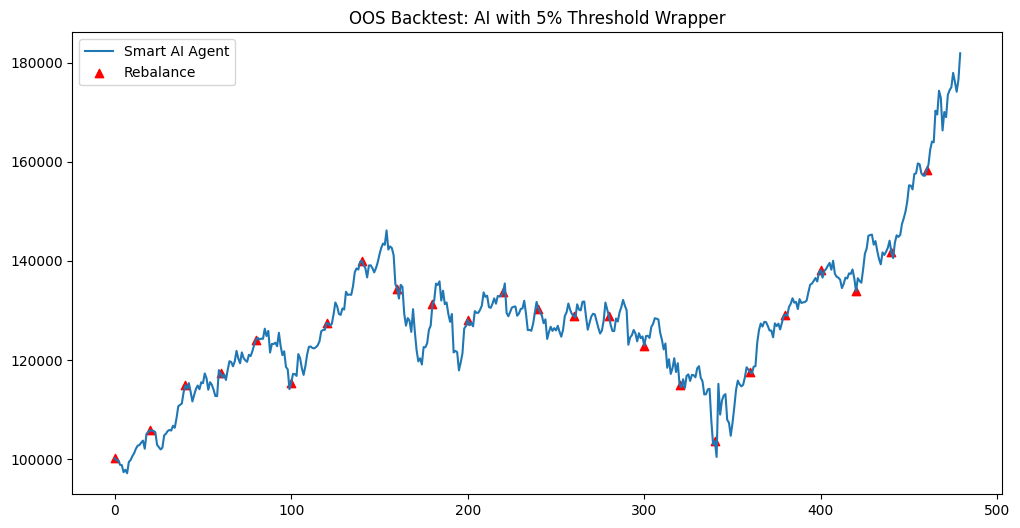

Total Return: 81.62%
Trades Executed: 24


In [8]:
# Run Backtest on TEST Data
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test)
# 1. Rerun Backtest with new logger
backtester = SmartBacktesterWithWeights(model, test_env, threshold=REBALANCE_THRESHOLD)
results = backtester.run()

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(results['nav'], label='Smart AI Agent')

# Plot Trade Markers
trades = results[results['action'] == 'TRADE']
plt.scatter(trades.index, trades['nav'], color='red', marker='^', label='Rebalance')

plt.title("OOS Backtest: AI with 5% Threshold Wrapper")
plt.legend()
plt.show()

# Stats
start_val = results['nav'].iloc[0]
end_val = results['nav'].iloc[-1]
roi = (end_val / start_val) - 1
print(f"Total Return: {roi*100:.2f}%")
print(f"Trades Executed: {len(trades)}")

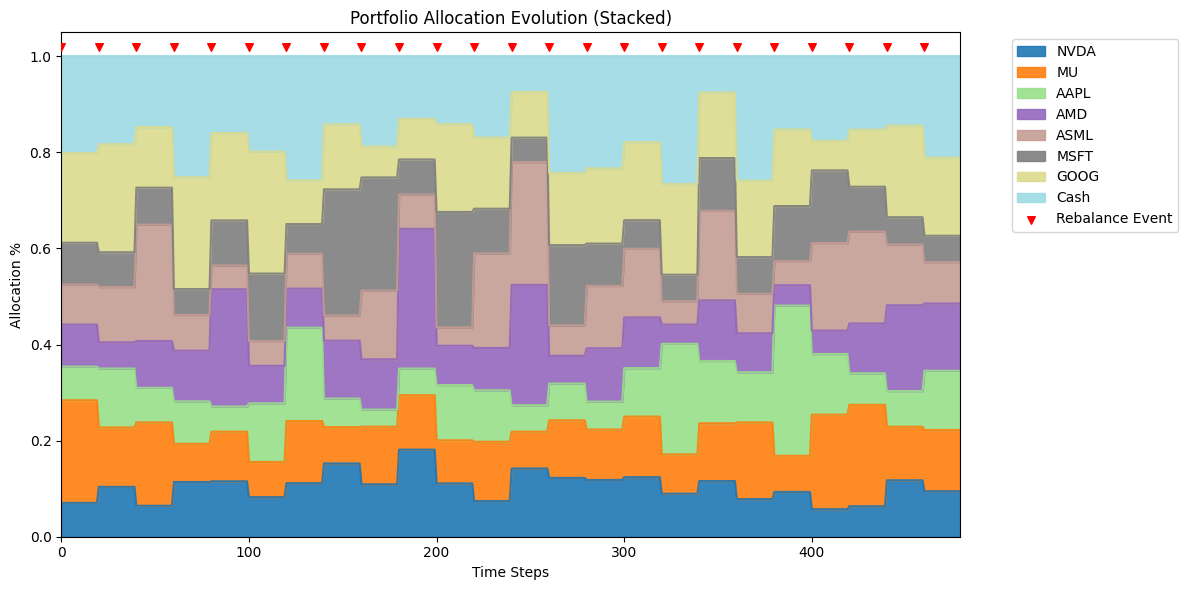

In [9]:
# 2. Process Weights Data
# Expand the 'weights' column (list of arrays) into a proper DataFrame
weight_cols = list(df_full.columns[:-1]) + ['Cash'] # Assets + Cash
weights_df = pd.DataFrame(results['weights'].tolist(), index=results.index, columns=weight_cols)

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Use a Stacked Area Plot
weights_df.plot.area(ax=ax, cmap='tab20', alpha=0.9)

# Overlay the Rebalance Points (Red Triangles)
# We plot them at y=1.05 (just above the chart) to see WHEN it acted
rebalance_indices = results[results['action'] == 'TRADE'].index
ax.scatter(rebalance_indices, [1.02]*len(rebalance_indices), 
           color='red', marker='v', s=30, label='Rebalance Event', zorder=10)

plt.title("Portfolio Allocation Evolution (Stacked)")
plt.ylabel("Allocation %")
plt.xlabel("Time Steps")
plt.margins(0, 0) # Remove white space on sides
plt.ylim(0, 1.05) # Give space for the markers
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()